r_s(eta_star) = 144.87 Mpc
k_D(eta_star) = 0.2560 Mpc^-1
lambda_D      = 3.91 Mpc

Grafico 3b salvo com sucesso.


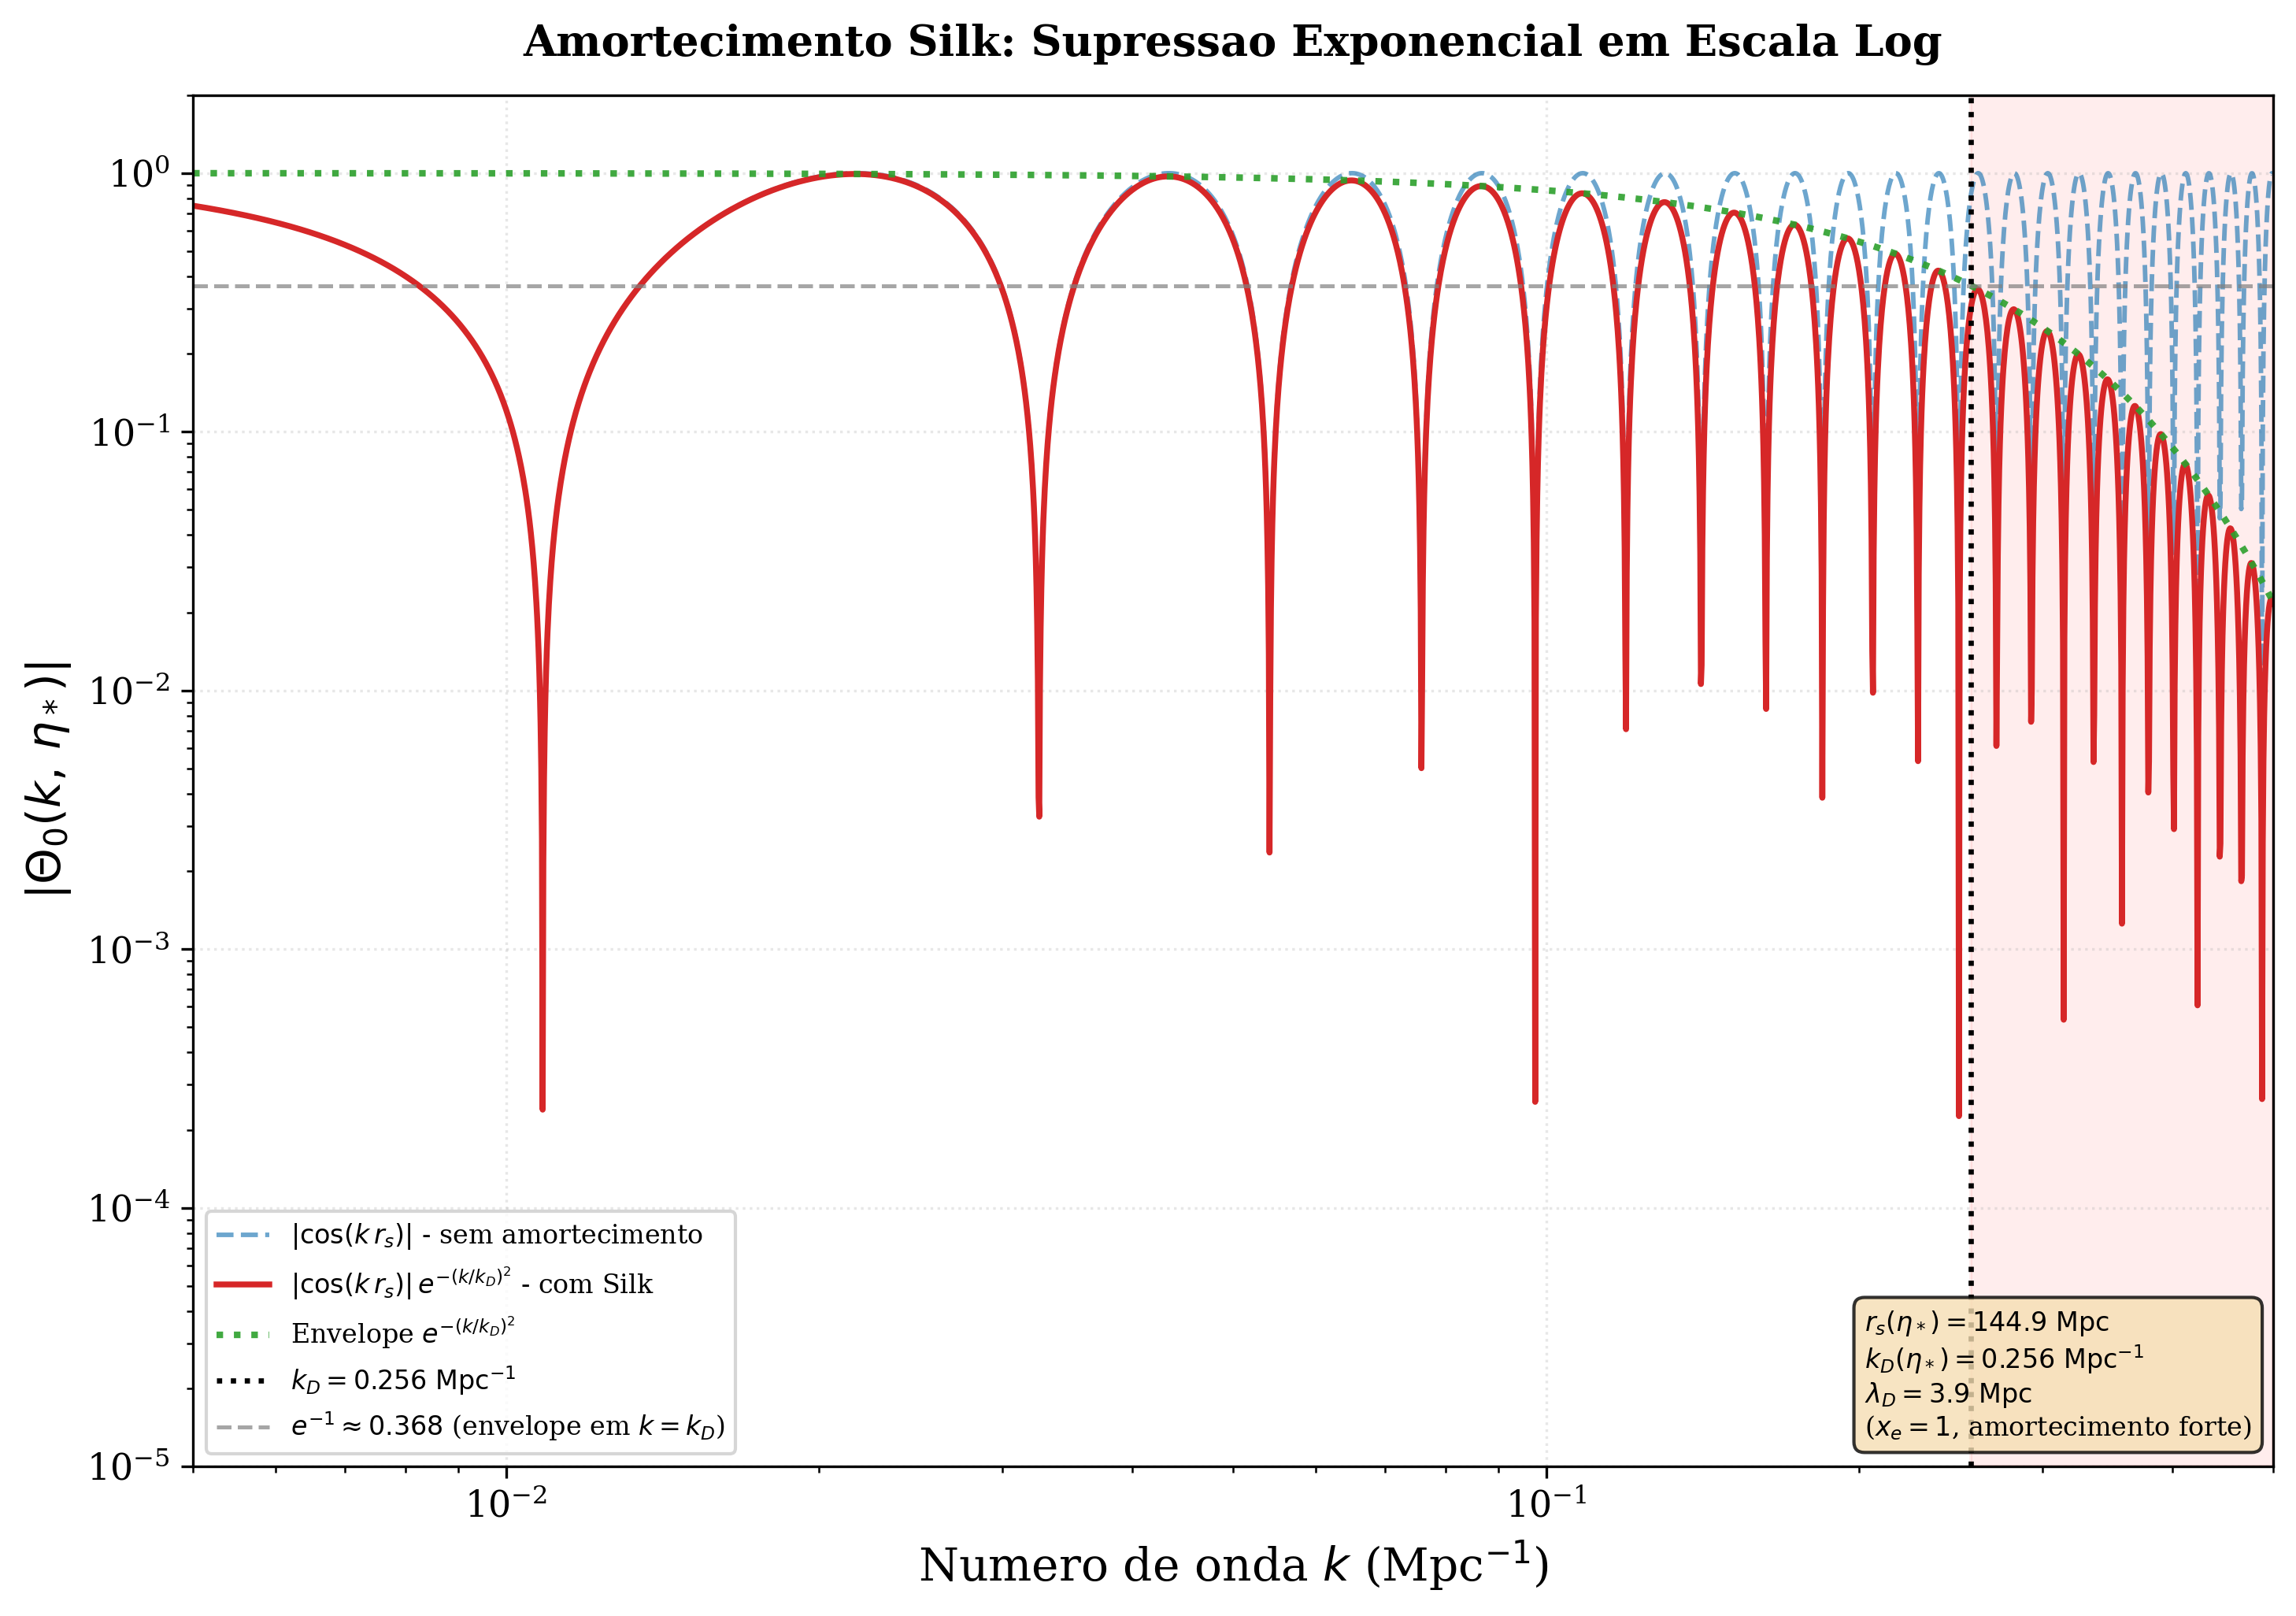


   k      k/k_D    |cos(k r_s)|    envelope   |Theta_amort|
------------------------------------------------------------
 0.010    0.039       0.1218        0.9985       0.1216   
 0.030    0.117       0.3582        0.9864       0.3533   
 0.060    0.234       0.7434        0.9465       0.7036   
 0.100    0.391       0.3425        0.8585       0.2940   
 0.150    0.586       0.9661        0.7094       0.6853   
 0.200    0.781       0.7654        0.5431       0.4157   
 0.300    1.172       0.8668        0.2532       0.2195   
 0.400    1.563       0.1716        0.0870       0.0149   


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate


# =============================================================================
# CONFIGURACOES DE ESTILO
# =============================================================================

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})


# =============================================================================
# PARAMETROS COSMOLOGICOS - Planck 2018
# =============================================================================

Omega_b_h2 = 0.0224
Omega_m = 0.315
h = 0.674

H0_si = h * 100 / 299792.458
Omega_r = 9.0e-5

z_star = 1090
z_max = 1e6


# Secao de choque de Thomson em Mpc^2
sigma_T_Mpc2 = (
    6.6524e-25
    / (3.08567758e24)**2
)

# Densidade bariônica relativa
Omega_b = Omega_b_h2 / h**2

# Densidade critica atual
rho_crit_0 = 2.77536627e11 * h**2

# Massa do hidrogenio em unidades de massa solar
m_H_Msun = 1.6735575e-27 / 1.98892e30

# Numero de barions por Mpc^3 no presente
n_b0_Mpc3 = (
    Omega_b
    * rho_crit_0
    / m_H_Msun
)


# =============================================================================
# FUNCAO DE EXPANSAO E TEMPO CONFORME
# =============================================================================

def E(z):
    """
    Funcao adimensional associada a H(z).
    """

    return np.sqrt(
        Omega_m * (1 + z)**3
        + Omega_r * (1 + z)**4
        + (1 - Omega_m - Omega_r)
    )


def eta_c(z):
    """
    Calcula o tempo conforme correspondente ao redshift z.
    """

    integrand = lambda zp: 1 / (H0_si * E(zp))

    value, _ = integrate.quad(
        integrand,
        z,
        z_max,
        limit=500
    )

    return value


# =============================================================================
# GRADE DE REDSHIFT E TEMPO CONFORME
# =============================================================================

N = 5000

z_grid = np.logspace(
    0,
    np.log10(z_max),
    N
)[::-1]


eta_raw = np.array([
    eta_c(z)
    for z in z_grid
])


# Reordena a grade em ordem crescente de tempo conforme
order = np.argsort(eta_raw)

eta_s = eta_raw[order]
z_s = z_grid[order]


# Tempo conforme na recombinacao
eta_star_val = eta_c(z_star)

idx_star = np.argmin(
    np.abs(eta_s - eta_star_val)
)


# =============================================================================
# PARAMETROS DO FLUIDO FOTON-BARION
#
# R(z), velocidade do som e horizonte sonico
# =============================================================================

def R_z(z):
    """
    Calcula R(z).
    """

    return (
        0.6
        * (Omega_b_h2 / 0.02)
        * (1 / (1 + z_star) / 1e-3)
        * (1 + z_star) / (1 + z)
    )


R_g = R_z(z_s)


c_s_g = 1 / np.sqrt(
    3 * (1 + R_g)
)


# Horizonte sonico acumulado
r_s_g = integrate.cumulative_trapezoid(
    c_s_g,
    eta_s,
    initial=0
)


rs_star = r_s_g[idx_star]


# =============================================================================
# ESCALA DE DAMPING k_D - Eq. 93
#
# Considera ionizacao completa, x_e = 1,
# no regime de tight coupling.
# =============================================================================

a_g = 1 / (1 + z_s)

# Densidade de eletrons
ne_g = (
    n_b0_Mpc3
    * (1 + z_s)**3
)

# Taxa de espalhamento de Thomson
tau_p_g = (
    ne_g
    * sigma_T_Mpc2
    * a_g
)


# Integrando para k_D^{-2}
kD_integrand = (
    1
    / (6 * (1 + R_g) * tau_p_g)
    * (
        R_g**2 / (1 + R_g)
        + 8 / 9
    )
)


kD2_inv = integrate.trapezoid(
    kD_integrand[:idx_star + 1],
    eta_s[:idx_star + 1]
)


kD_star = 1 / np.sqrt(kD2_inv)

lambda_D = 1 / kD_star


print(
    f"r_s(eta_star) = {rs_star:.2f} Mpc"
)

print(
    f"k_D(eta_star) = {kD_star:.4f} Mpc^-1"
)

print(
    f"lambda_D      = {lambda_D:.2f} Mpc"
)


# =============================================================================
# CURVAS
#
# A escala logaritmica exige valores positivos.
#
# A funcao |cos(k r_s)| apresenta zeros nos nos acusticos.
# Para evitar log(0), usamos um valor minimo muito pequeno.
# =============================================================================

k = np.logspace(
    np.log10(0.005),
    np.log10(0.5),
    3000
)


epsilon = 1e-12


# Envelope de amortecimento de Silk
envelope = np.exp(
    -(k / kD_star)**2
)


# Oscilacao com amortecimento
theta_damped = np.maximum(
    np.abs(np.cos(k * rs_star)) * envelope,
    epsilon
)


# Oscilacao sem amortecimento
theta_nodamp = np.maximum(
    np.abs(np.cos(k * rs_star)),
    epsilon
)


# =============================================================================
# GRAFICO
# =============================================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)


# Solucao sem amortecimento
ax.plot(
    k,
    theta_nodamp,
    label=r'$|\cos(k\,r_s)|$ - sem amortecimento',
    color='#1f77b4',
    linestyle='--',
    linewidth=1.4,
    alpha=0.65
)


# Solucao com amortecimento de Silk
ax.plot(
    k,
    theta_damped,
    label=r'$|\cos(k\,r_s)|\,e^{-(k/k_D)^2}$ - com Silk',
    color='#d62728',
    linestyle='-',
    linewidth=1.8
)


# Envelope exponencial
ax.plot(
    k,
    envelope,
    label=r'Envelope $e^{-(k/k_D)^2}$',
    color='#2ca02c',
    linestyle=':',
    linewidth=2.0,
    alpha=0.9
)


# =============================================================================
# MARCACOES IMPORTANTES
# =============================================================================

# Escala de damping k_D
ax.axvline(
    x=kD_star,
    color='black',
    linestyle=':',
    linewidth=1.6,
    label=rf'$k_D = {kD_star:.3f}\ \mathrm{{Mpc}}^{{-1}}$'
)


# Nivel 1/e do envelope
ax.axhline(
    y=np.exp(-1),
    color='gray',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label=r'$e^{-1} \approx 0.368$ (envelope em $k=k_D$)'
)


# Regiao em que o amortecimento se torna significativo
ax.axvspan(
    kD_star,
    0.5,
    alpha=0.07,
    color='red'
)


# =============================================================================
# EIXOS E FORMATACAO
# =============================================================================

ax.set_xlabel(
    r'Numero de onda $k$ (Mpc$^{-1}$)',
    fontsize=14
)

ax.set_ylabel(
    r'$|\Theta_0(k,\,\eta_*)|$',
    fontsize=14
)


ax.set_xscale('log')
ax.set_yscale('log')


ax.set_xlim(
    0.005,
    0.5
)

ax.set_ylim(
    1e-5,
    2.0
)


ax.tick_params(
    labelsize=11
)


ax.legend(
    loc='lower left',
    frameon=True,
    fontsize=8
)


ax.grid(
    True,
    alpha=0.3,
    linestyle=':'
)


ax.set_title(
    'Amortecimento Silk: Supressao Exponencial em Escala Log',
    fontsize=13,
    fontweight='bold',
    pad=12
)


# =============================================================================
# INFORMACOES NO GRAFICO
# =============================================================================

ax.text(
    0.8035,
    0.115,
    rf'$r_s(\eta_*) = {rs_star:.1f}\ \mathrm{{Mpc}}$' '\n'
    rf'$k_D(\eta_*) = {kD_star:.3f}\ \mathrm{{Mpc}}^{{-1}}$' '\n'
    rf'$\lambda_D = {lambda_D:.1f}\ \mathrm{{Mpc}}$' '\n'
    r'($x_e = 1$, amortecimento forte)',
    transform=ax.transAxes,
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.8,
        pad=0.4
    ),
    fontsize=8,
    verticalalignment='top'
)


# =============================================================================
# SALVAMENTO
# =============================================================================

plt.tight_layout()


plt.savefig(
    'grafico3b_amortecimento_silk_log.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'grafico3b_amortecimento_silk_log.pdf',
    dpi=300,
    bbox_inches='tight'
)


print("\nGrafico 3b salvo com sucesso.")


plt.show()


# =============================================================================
# VERIFICACAO QUANTITATIVA
# =============================================================================

print(
    f"\n{'k':^8} "
    f"{'k/k_D':^8} "
    f"{'|cos(k r_s)|':^14} "
    f"{'envelope':^12} "
    f"{'|Theta_amort|':^12}"
)

print("-" * 60)


for k_test in [
    0.01,
    0.03,
    0.06,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40
]:

    damping_factor = np.exp(
        -(k_test / kD_star)**2
    )

    oscillation = abs(
        np.cos(k_test * rs_star)
    )

    theta_amort = (
        oscillation
        * damping_factor
    )

    print(
        f"{k_test:^8.3f} "
        f"{k_test / kD_star:^8.3f} "
        f"{oscillation:^14.4f} "
        f"{damping_factor:^12.4f} "
        f"{theta_amort:^12.4f}"
    )